# Final Algorithm Comparison

Comprehensive comparison of all nine model-free RL algorithms on the Fox (2016)
8x8 Gridworld cost-minimisation task.

**Prerequisite:** run `python experiments/run_all.py` first to populate
`experiments/results/` with `.npy` result files.

| Group | Algorithms |
|-------|------------|
| TD control (off-policy) | Q-learning, Double Q-learning, G-learning |
| TD control (on-policy)  | SARSA, Expected SARSA |
| Policy gradient         | REINFORCE, REINFORCE+baseline |
| Actor-Critic            | One-step AC, AC(lambda) |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from experiments.run_all import (
    load_config, run_episode,
    _make_q_learning, _make_double_q, _make_sarsa,
    _make_expected_sarsa, _make_g_learning,
    _make_reinforce, _make_reinforce_baseline,
    _make_actor_critic, _make_actor_critic_lambda,
)
from environment.gridworld import GridWorldEnv
from utils.plotting import (
    plot_learning_curves, plot_multi_curves,
    plot_value_heatmap, plot_vstar_heatmap,
    plot_policy_arrows, plot_summary_bar,
    plot_multi_heatmap_grid, plot_multi_policy_grid,
    save_figure,
)
from utils.metrics import V_STAR, policy_eval_error

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RESULTS_DIR = Path('..') / 'experiments' / 'results'

## 1. Load Pre-computed Results

In [2]:
DISPLAY = {
    'q_learning':          'Q-learning',
    'double_q_learning':   'Double Q',
    'sarsa':               'SARSA',
    'expected_sarsa':      'Expected SARSA',
    'g_learning':          'G-learning',
    'reinforce':           'REINFORCE',
    'reinforce_baseline':  'REINFORCE+baseline',
    'actor_critic':        'Actor-Critic',
    'actor_critic_lambda': 'AC(lambda)',
}

results = {}
for key, label in DISPLAY.items():
    path = RESULTS_DIR / f'{key}_metrics.npy'
    if path.exists():
        res = np.load(path, allow_pickle=True).item()
        results[label] = res
        print(f'  {label:<22}  runs={res["n_runs"]}  eps={res["n_episodes"]}  '
              f'final_policy_err={res["policy_err"][:, -1].mean():.4f}')
    else:
        print(f'  {label:<22}  MISSING -> run experiments/run_all.py')

print(f'\n{len(results)}/{len(DISPLAY)} algorithms available.')

  Q-learning              runs=10  eps=1500  final_policy_err=0.1099
  Double Q                runs=10  eps=1500  final_policy_err=0.3303
  SARSA                   runs=10  eps=1500  final_policy_err=0.5647
  Expected SARSA          runs=10  eps=1500  final_policy_err=0.2430
  G-learning              runs=10  eps=1500  final_policy_err=0.1125
  REINFORCE               runs=10  eps=1500  final_policy_err=0.9340
  REINFORCE+baseline      runs=10  eps=1500  final_policy_err=0.6862
  Actor-Critic            runs=10  eps=1500  final_policy_err=0.4200
  AC(lambda)              runs=10  eps=1500  final_policy_err=0.5933

9/9 algorithms available.


## 2. Absolute Relative Error (Value Quality)

`mean |V_est(s) - V*(s)| / V*(s)` over valid states.

> **Caveat for policy-gradient agents:** `V_est` is the value of the *current
> policy*, not the optimal value. Large absolute errors for REINFORCE / AC early
> in training are expected and do not directly reflect policy quality.

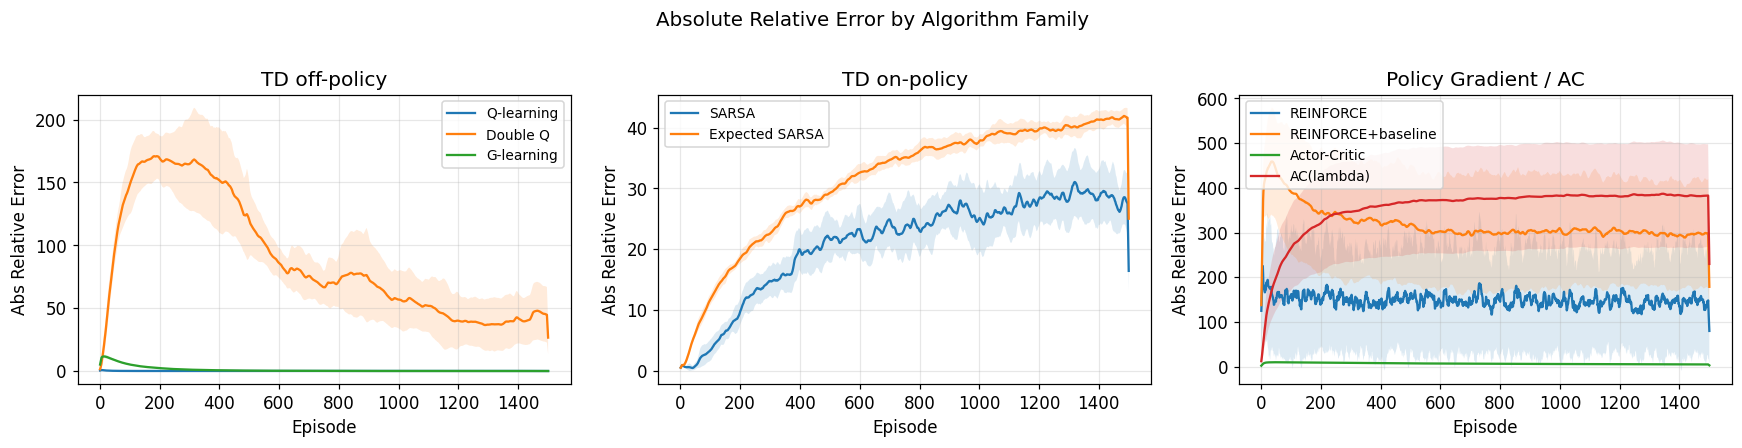

In [3]:
td_off = {k: results[k] for k in ['Q-learning', 'Double Q', 'G-learning'] if k in results}
td_on  = {k: results[k] for k in ['SARSA', 'Expected SARSA'] if k in results}
pg_ac  = {k: results[k] for k in ['REINFORCE', 'REINFORCE+baseline',
                                    'Actor-Critic', 'AC(lambda)'] if k in results}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for grp, ax, title in [
    (td_off, axes[0], 'TD off-policy'),
    (td_on,  axes[1], 'TD on-policy'),
    (pg_ac,  axes[2], 'Policy Gradient / AC'),
]:
    for name, res in grp.items():
        plot_learning_curves(res, 'abs_err', label=name, ax=ax, smooth=10)
    ax.set_title(title)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Abs Relative Error')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Absolute Relative Error by Algorithm Family', fontsize=13, y=1.01)
fig.tight_layout()
save_figure(fig, '05_abs_err_grouped')
plt.show()

## 3. Policy Evaluation Error (Primary Metric)

`mean |V^pi(s) - V*(s)| / V*(s)` — how good is the *induced greedy policy*?
This is the correct cross-family comparison metric. Recorded every 50 episodes.

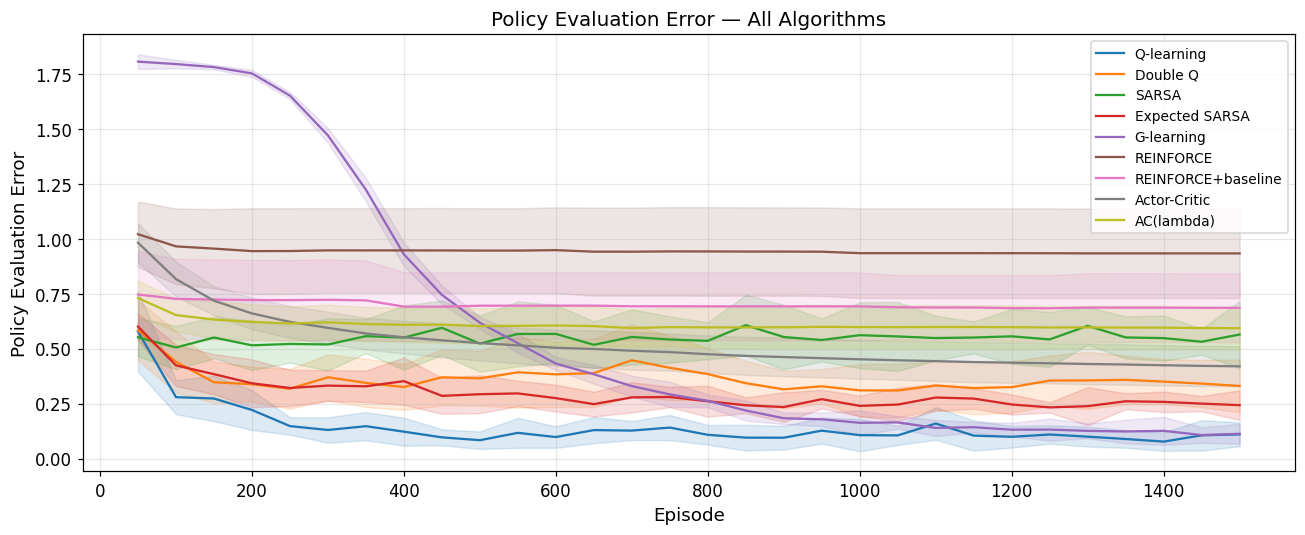

In [4]:
fig = plot_multi_curves(
    results, metric='policy_err',
    title='Policy Evaluation Error — All Algorithms',
    figsize=(12, 5),
)
save_figure(fig, '05_policy_err_all')
plt.show()

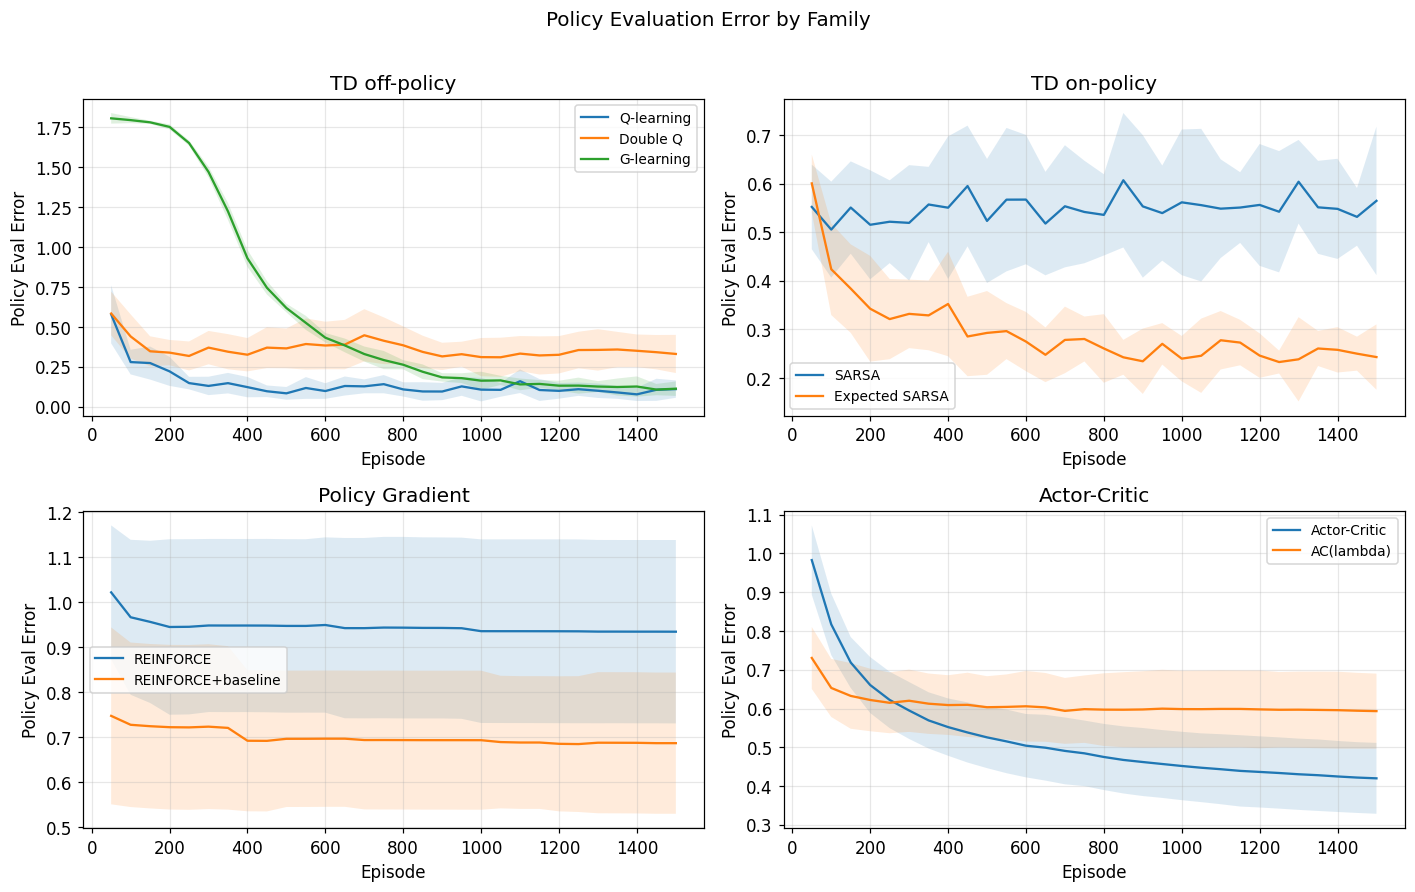

In [5]:
groups = [
    ('TD off-policy',       ['Q-learning', 'Double Q', 'G-learning']),
    ('TD on-policy',        ['SARSA', 'Expected SARSA']),
    ('Policy Gradient',     ['REINFORCE', 'REINFORCE+baseline']),
    ('Actor-Critic',        ['Actor-Critic', 'AC(lambda)']),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, (grp_name, members) in enumerate(groups):
    grp = {k: results[k] for k in members if k in results}
    for name, res in grp.items():
        plot_learning_curves(res, 'policy_err', label=name, ax=axes[i])
    axes[i].set_title(grp_name)
    axes[i].set_xlabel('Episode')
    axes[i].set_ylabel('Policy Eval Error')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Policy Evaluation Error by Family', fontsize=13, y=1.01)
fig.tight_layout()
save_figure(fig, '05_policy_err_grouped')
plt.show()

## 4. Signed Relative Error (Bias)

Positive = over-estimate (optimistic).  Negative = under-estimate (pessimistic).
Hard-min algorithms (Q-learning, SARSA) tend to be pessimistic early in training.

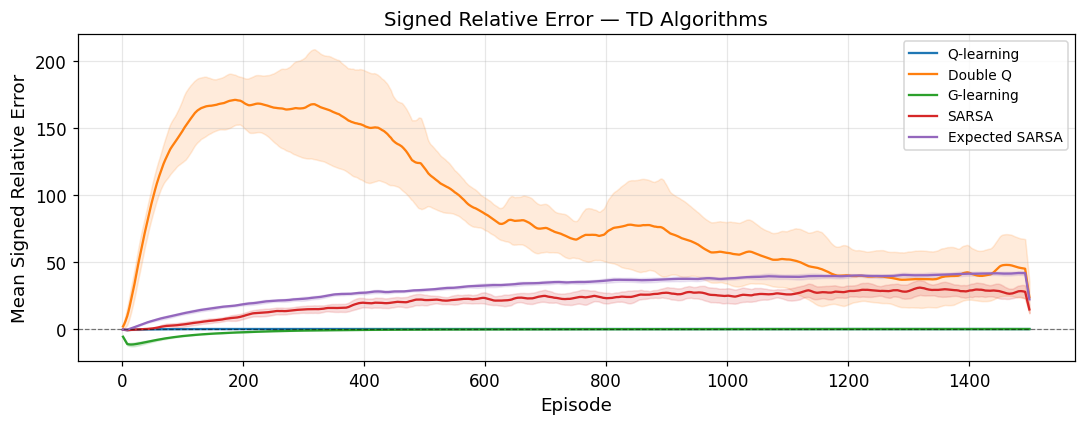

In [6]:
td_all = {k: results[k] for k in
          ['Q-learning', 'Double Q', 'G-learning', 'SARSA', 'Expected SARSA']
          if k in results}

fig = plot_multi_curves(
    td_all, metric='signed_err',
    title='Signed Relative Error — TD Algorithms',
    smooth=15, figsize=(10, 4),
)
for ax in fig.axes:
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
save_figure(fig, '05_signed_err_td')
plt.show()

## 5. Value Function Heatmaps

Single-seed snapshot (seed 42, 1500 episodes). For statistical conclusions
use the multi-run metrics in sections 2-4.

In [7]:
cfg = load_config()
n_eps  = cfg['environment']['n_episodes']
max_st = cfg['environment']['max_steps_per_episode']

FACTORIES = [
    ('Q-learning',         _make_q_learning),
    ('Double Q',           _make_double_q),
    ('SARSA',              _make_sarsa),
    ('Expected SARSA',     _make_expected_sarsa),
    ('G-learning',         _make_g_learning),
    ('REINFORCE',          _make_reinforce),
    ('REINFORCE+baseline', _make_reinforce_baseline),
    ('Actor-Critic',       _make_actor_critic),
    ('AC(lambda)',         _make_actor_critic_lambda),
]

trained = {}   # name -> agent
for name, factory in FACTORIES:
    agent = factory(np.random.default_rng(42), cfg)
    env   = GridWorldEnv(np.random.default_rng(43))
    for ep in range(n_eps):
        run_episode(agent, env, max_st, ep)
    trained[name] = agent
    pe = policy_eval_error(agent.get_policy())
    print(f'  {name:<22}  policy_err={pe:.4f}')

  Q-learning              policy_err=0.0447
  Double Q                policy_err=0.1779
  SARSA                   policy_err=0.7490
  Expected SARSA          policy_err=0.3895
  G-learning              policy_err=0.1259
  REINFORCE               policy_err=0.9550
  REINFORCE+baseline      policy_err=0.6038
  Actor-Critic            policy_err=0.5830
  AC(lambda)              policy_err=0.5130


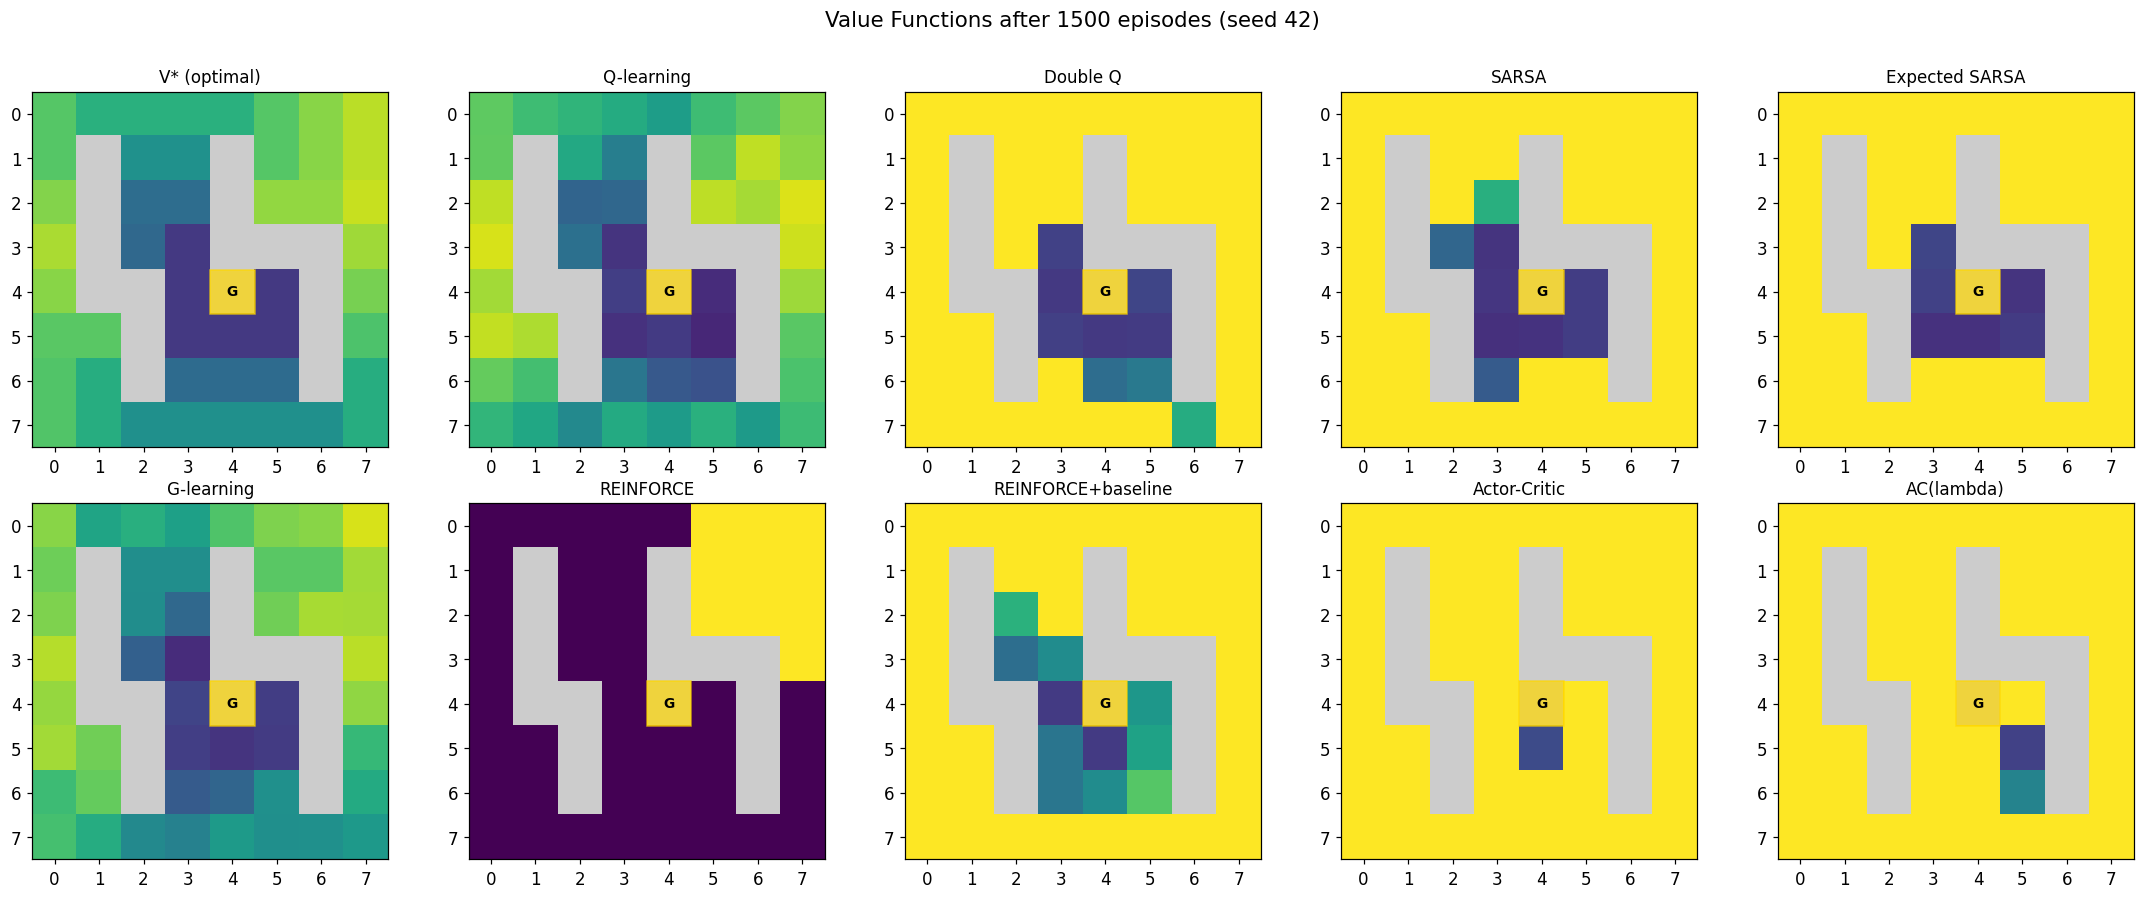

In [8]:
val_list = [('V* (optimal)', V_STAR)] + [
    (name, agent.get_value_estimate()) for name, agent in trained.items()
]

fig = plot_multi_heatmap_grid(
    val_list, n_cols=5, vmin=0, vmax=6,
    suptitle='Value Functions after 1500 episodes (seed 42)',
)
save_figure(fig, '05_value_heatmaps')
plt.show()

## 6. Policy Visualisation

Arrow = highest-probability action at each valid state.

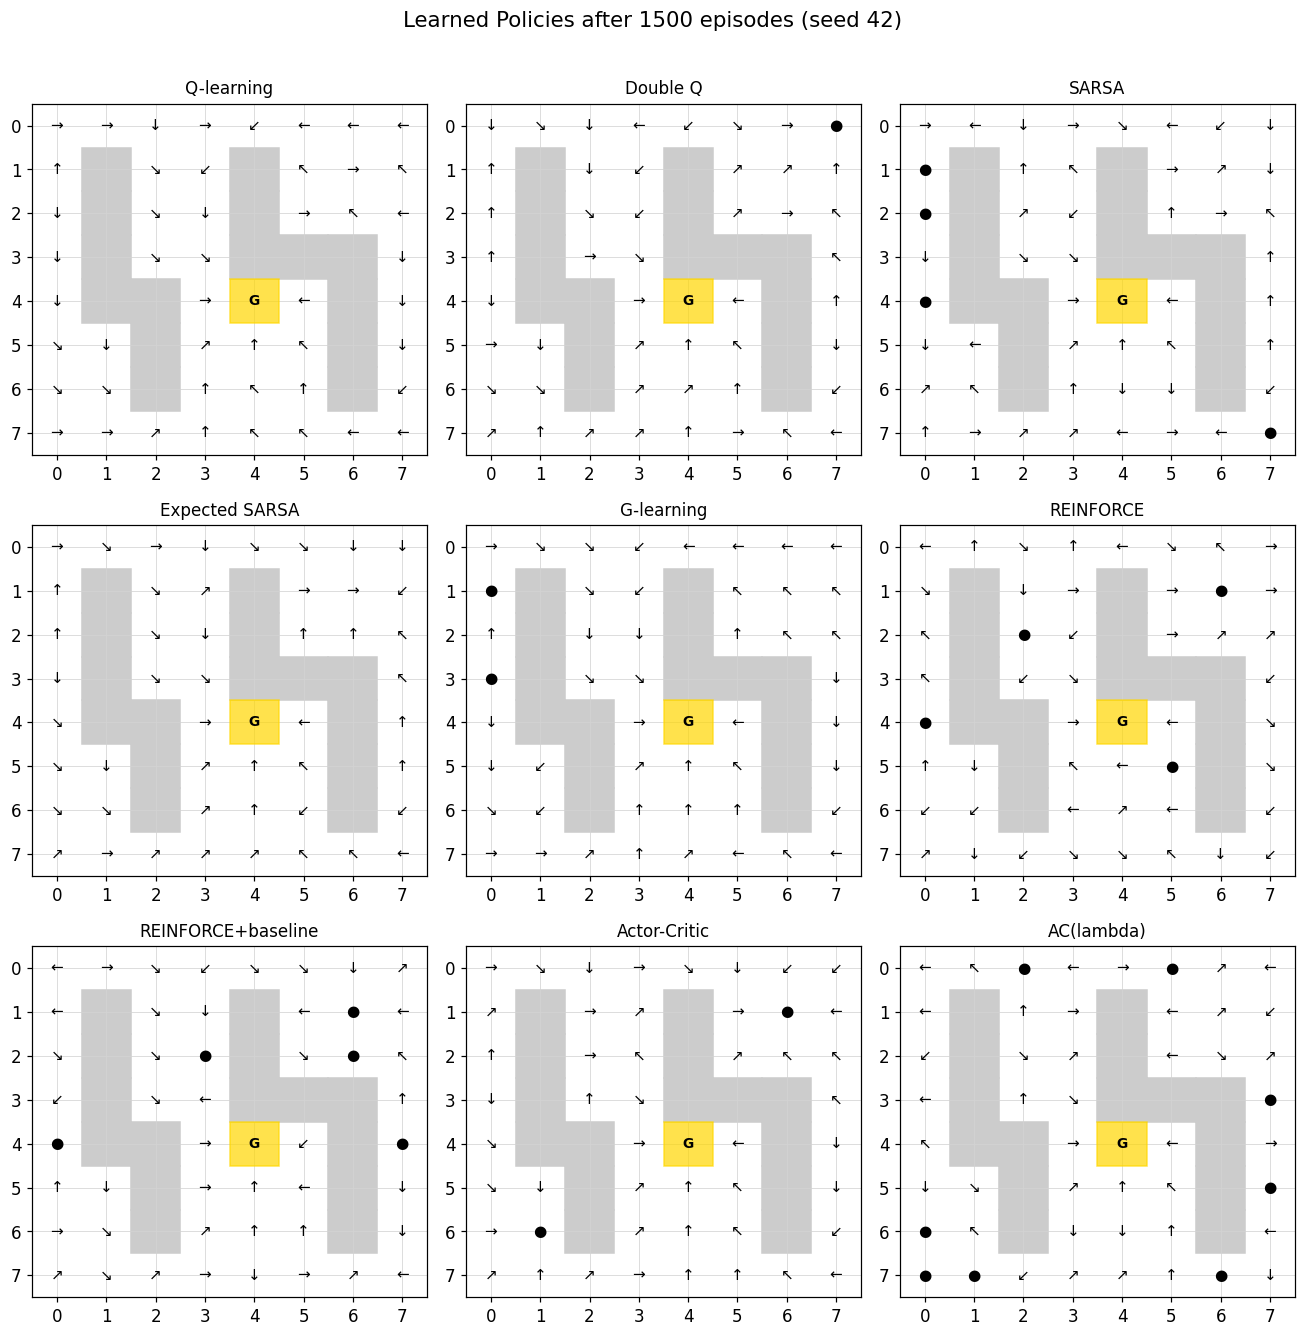

In [9]:
pol_list = [(name, agent.get_policy()) for name, agent in trained.items()]

fig = plot_multi_policy_grid(
    pol_list, n_cols=3,
    suptitle='Learned Policies after 1500 episodes (seed 42)',
)
save_figure(fig, '05_policy_grids')
plt.show()

## 7. Summary Statistics Table

Final-episode metrics across all runs. `policy_err` is the primary metric.

In [10]:
print(f"{'Algorithm':<22}  {'abs_err':>10}  {'abs_std':>8}  "
      f"{'pol_err':>10}  {'pol_std':>8}")
print('-' * 68)

final_pol = {}
for label, res in results.items():
    ae_m = res['abs_err'][:, -1].mean()
    ae_s = res['abs_err'][:, -1].std()
    pe_m = res['policy_err'][:, -1].mean()
    pe_s = res['policy_err'][:, -1].std()
    print(f'{label:<22}  {ae_m:>10.4f}  {ae_s:>8.4f}  {pe_m:>10.4f}  {pe_s:>8.4f}')
    final_pol[label] = pe_m

best = min(final_pol, key=final_pol.get)
print(f'\nBest:  {best}  ({final_pol[best]:.4f})')

Algorithm                  abs_err   abs_std     pol_err   pol_std
--------------------------------------------------------------------
Q-learning                  0.1017    0.0148      0.1099    0.0544
Double Q                   44.0185   21.8048      0.3303    0.1196
SARSA                      27.3471    5.2143      0.5647    0.1530
Expected SARSA             41.5859    1.4882      0.2430    0.0673
G-learning                  0.0888    0.0125      0.1125    0.0453
REINFORCE                 129.1491  162.7476      0.9340    0.2038
REINFORCE+baseline        299.6194  120.6261      0.6862    0.1569
Actor-Critic                4.9879    0.2067      0.4200    0.0914
AC(lambda)                382.6378  114.7446      0.5933    0.0967

Best:  Q-learning  (0.1099)


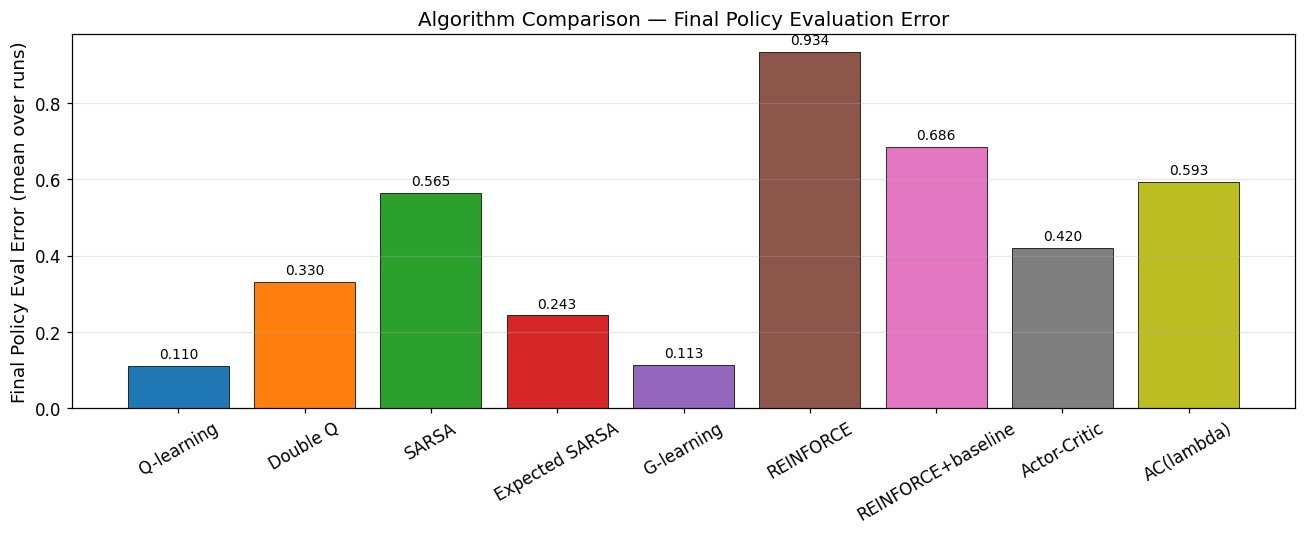

In [11]:
fig = plot_summary_bar(
    final_pol,
    metric_label='Final Policy Eval Error (mean over runs)',
    title='Algorithm Comparison — Final Policy Evaluation Error',
    figsize=(12, 5),
)
save_figure(fig, '05_summary_bar')
plt.show()

## 8. Convergence Speed

In [12]:
THRESHOLD = 0.15   # adjust as needed

print(f'Episodes until mean policy_err < {THRESHOLD}:')
print('-' * 45)

rows = []
for label, res in results.items():
    x    = res['checkpoint_eps'] + 1
    mean = res['policy_err'].mean(axis=0)
    idx  = np.where(mean < THRESHOLD)[0]
    ep   = int(x[idx[0]]) if len(idx) > 0 else None
    rows.append((ep if ep else 9999, label, ep))

for _, label, ep in sorted(rows):
    ep_str = str(ep) if ep else f'> {int(x[-1])} (never)'
    print(f'  {label:<22}  {ep_str}')

Episodes until mean policy_err < 0.15:
---------------------------------------------
  Q-learning              250
  G-learning              1100
  AC(lambda)              > 1500 (never)
  Actor-Critic            > 1500 (never)
  Double Q                > 1500 (never)
  Expected SARSA          > 1500 (never)
  REINFORCE               > 1500 (never)
  REINFORCE+baseline      > 1500 (never)
  SARSA                   > 1500 (never)


## 9. Conclusions

### Interpretation guide

| Metric | What it measures | Best for |
|--------|-----------------|----------|
| `abs_err` | How close V_est is to V* | TD algorithms |
| `signed_err` | Optimism / pessimism bias | TD algorithms |
| `policy_err` | Quality of induced policy | All algorithms |

### TD control

All five TD algorithms (Q, Double-Q, SARSA, Expected SARSA, G-learning) learn
a Q-table. They benefit from a direct Bellman signal every step, so they
converge steadily. Double-Q partially mitigates minimisation bias by decoupling
action selection from evaluation. Expected SARSA reduces variance versus SARSA
by averaging over all next actions analytically.

### Policy gradient

REINFORCE uses high-variance Monte-Carlo returns. Adding a learned V-baseline
reduces gradient variance without bias and typically accelerates policy_err
convergence. Both variants are episodic and do not update between steps.

### Actor-Critic

One-step AC applies TD updates online (lower variance than REINFORCE, but
higher bias than full-return methods). AC(lambda) uses eligibility traces
to interpolate between one-step TD and Monte-Carlo returns.

### Why policy_err is the right comparison

For value-based methods, `abs_err` and `policy_err` are aligned: a better
Q-table induces a better policy. For policy-gradient agents, `V_est` is the
value of the *current policy*, which starts very high (random policy hits walls
often, costing 1000 each). Comparing `abs_err` across families therefore
conflates algorithm quality with value-estimate semantics. Policy eval error
measures what we actually care about: how much does following the learned
policy cost compared to the optimal?